
Tensors
=======

*Tutorial adapted from https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html*

Tensors are a specialized data structure that are very similar to arrays
and matrices. In PyTorch, we use tensors to encode the inputs and
outputs of a model, as well as the model's parameters.

If you know [NumPy](https://numpy.org/), the python's library for numerical calculations,
tensors are similar to ndarrays, except
that tensors can run on GPUs or other hardware accelerators. In fact,
tensors and NumPy arrays can often share the same underlying memory,
eliminating the need to copy data. Tensors are also
optimized for automatic differentiation (we\'ll see more of that
on the second labs).


In [ ]:
import torch
import numpy as np

%matplotlib inline

Initializing a Tensor
=====================

**From python lists**

The data type is
automatically inferred.


In [ ]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
print(x_data)
print(x_data.dtype)

**From a NumPy array**


In [ ]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_data)
print(x_data.dtype)

**From another tensor**

The new tensor retains the properties (shape, datatype) of the argument
tensor, unless explicitly overridden.


In [ ]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n type: {x_ones.dtype}\n")

x_ones_float = torch.ones_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_ones_float} \n type: {x_ones_float.dtype}\n")

**With random or constant values**

`shape` is a tuple of tensor dimensions. In the functions below, it
determines the dimensionality of the output tensor.


In [ ]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Uniform Tensor from 0 to 1: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

------------------------------------------------------------------------


Attributes of a Tensor
======================

Tensor attributes describe their shape, datatype, and the device on
which they are stored.


In [ ]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

**How multidimensional tensors are stored in memory**

PyTorch tensors are stored in memory as contiguous 1D arrays, regardless of their logical dimensionality. The multidimensional structure is created through metadata that describes how to interpret this flat memory layout. For instance, tensors of shape (2, 3) and (3, 2) can have the same underlying storage (of 6 elements). The difference between them would be a parameter called *stride*. It tells pytorch how many elements to skip when iterating through a selected dimension.

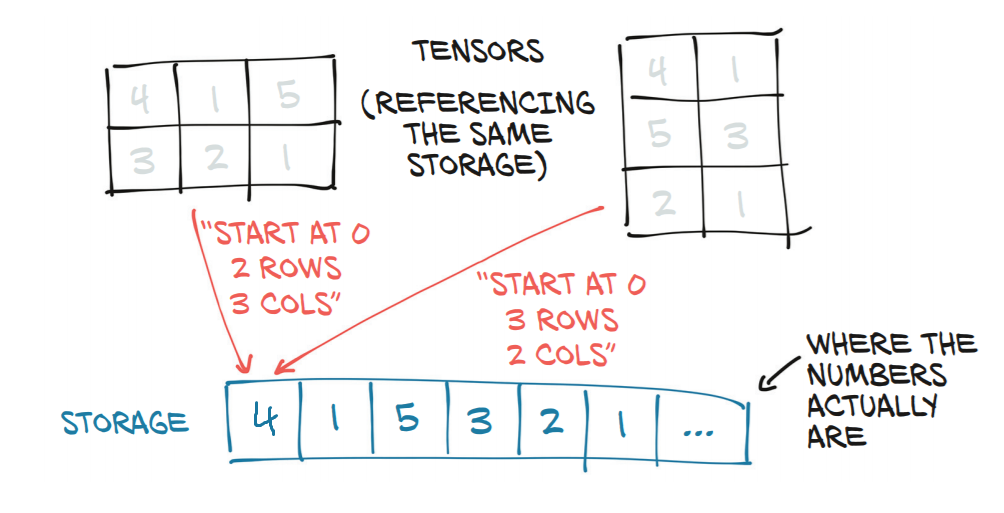

source: https://stackoverflow.com/questions/42479902/what-does-view-do-in-pytorch

In [ ]:
storage = torch.tensor([4, 1, 5, 3, 2, 1])
tensor_a = storage.view(2, 3)  # we learn more about views below
tensor_b = storage.view(3, 2)
print(f'storage: {storage}\n')

print(f'tensor_a: {tensor_a}')
print(f'tensor_a stride: {tensor_a.stride()}')
print(f'Moving through the first dimension of tensor_a, we increment the index of storage by {tensor_a.stride()[0]}\n')

print(f'tensor_b: {tensor_b}')
print(f'tensor_b stride: {tensor_b.stride()}')
print(f'Moving through the first dimension of tensor_b, we increment the index of storage by {tensor_b.stride()[0]}')



There are numerous operations in pytorch that get easier to understand once we remember that all tensors are stored as 1D arrays.

------------------------------------------------------------------------


Operations on Tensors
=====================

Over 1200 tensor operations, including arithmetic, linear algebra,
matrix manipulation (transposing, indexing, slicing), sampling and more
are comprehensively described
[here](https://pytorch.org/docs/stable/torch.html).

Each of these operations can be run on the CPU and
[Accelerator](https://pytorch.org/docs/stable/torch.html#accelerators)
such as CUDA, MPS, MTIA, or XPU.

By default, tensors are created on the CPU. We need to explicitly move
tensors to the accelerator using `.to` method (after checking for
accelerator availability). Keep in mind that copying large tensors
across devices can be expensive in terms of time and memory!


In [ ]:
if not torch.cuda.is_available():
    raise Exception('CUDA not available!')
tensor = tensor.to('cuda')
print(f"Tensor is now stored on: {tensor.device}")

In practice, with deep networks, we typically move everything
to GPU as soon as possible, do all the calculations there
and only move it back if we want to save/visualize something.

Below, you'll find some operations on Tensors that might become
useful over the course of the laboratories.
You don't have to memorize all of them,
just know where to look for them.


### **Standard numpy-like indexing, slicing and masking:**


In [ ]:
tensor = torch.randint(low=0, high=100, size=(4, 3))
print(f"Tensor: {tensor}")
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[:, -1]}")
tensor[:,1] = -1
print(tensor)

boolean_mask = tensor > 50
print(f'boolean_mask: {boolean_mask}')
masked_tensor = tensor[boolean_mask]
print(f'masked_tensor (note how it\'t flattened to 1D): {masked_tensor}')
tensor[boolean_mask] = 50
print(f'tensor after truncating elements higher than 50 using the mask: {tensor}')


Rows/columns can be confusing. Luckily, we'll be mostly talking about samples (elements from the dataset) and features (values describing each sample). Sample indices are *major* indices (meaning the first index), and all other indices refer to features.

In [ ]:
tensor = torch.randint(low=0, high=100, size=(4, 10_000))
print(f'This tensor could represent {tensor.shape[0]} samples, each having {tensor.shape[1]} features')
print(f'First sample: {tensor[0]}')

tensor = torch.randint(low=0, high=256, size=(4, 1280, 720, 3))
print(
    f'This tensor could represent {tensor.shape[0]} samples, '
    f'each being an image {tensor.shape[1]} in width '
    f'and {tensor.shape[2]} in height, {tensor.shape[3]} channels (RGB) for each pixel, '
    f'which would be {torch.tensor(tensor.shape[1:]).prod()} features in total'
)
# print(f'First sample: {tensor[0]}')


It's typical to represent batches of numerical data with 2D Tensors and batches of images with 4D Tensors.

We can see why deep learning's usefulness originated with images: samples that have 1280x720x3 features might be too complex for simpler methods.

### **Arithmetic operations**

Much like with NumPy arrays, Tensor operations work much faster when they are applied on the whole object, instead of iterating through its elements.

In [ ]:
import time

# Create random square matrices
size = 100
a = torch.randn(size, size)
b = torch.randn(size, size)

# Iterative matrix multiplication
start = time.time()
result_iter = torch.zeros(size, size)
for i in range(size):
    for j in range(size):
        for k in range(size):
            result_iter[i, j] += a[i, k] * b[k, j]
iter_time = time.time() - start

# Vectorized approach
start = time.time()
result_vec = a @ b
vec_time = time.time() - start

print(f"Iterative:  {iter_time:.4f} seconds")
print(f"Vectorized: {vec_time:.6f} seconds")

**Addition**

In [ ]:
# in principle, adding two tensors is allowed when they are of the same shape:
tensor_a = torch.tensor([1, 2])
tensor_b = torch.tensor([-1, 1])
tensor_sum = tensor_a + tensor_b
print(tensor_sum)
tensor_difference = tensor_a - tensor_b
print(tensor_difference)

tensor_c = torch.tensor([1, 2, 3])
try:
    tensor_a + tensor_c
except RuntimeError as e:
    print(f'Addition of differing shapes failed with exception: {e}')

**Broadcasting**

As the exception message from the cell above suggests, some additions of differing shapes are allowed. That's thanks to an operation in pytorch and numpy called **broadcasting**. When two tensors are involved in an elementwise operation, NumPy/PyTorch tries to broadcast them so that they both have the same shape. The rules of broadcasting are as follows:

1. The element with fewer dimensions can be appended dummy dimensions (of size 1) to the start
2. Dummy dimensions (of size 1) can be expanded to match the dimension of the other element

In [ ]:
def showcase_broadcasting(a: torch.Tensor, b: torch.Tensor):
    try:
        print(f'Adding {a.shape} and {b.shape} gives {(a+b).shape}')
    except RuntimeError:
        print(f'Adding {a.shape} and {b.shape} gives a RuntimeError')


showcase_broadcasting(torch.ones([3, 2]), torch.ones([2]))
print(f'This is broadcastable, as (2) -> (1, 2) -> (3, 2)\n')

showcase_broadcasting(torch.ones([7, 5]), torch.ones([7]))
print(f'That\'t not broadcastable, as (7) -> (1, 7), which has no way of getting to (7, 5)\n')

showcase_broadcasting(torch.ones([5, 1, 4]), torch.ones([1, 3, 4]))
print(f'Sometimes, both tensors are expanded during broadcasting\n')

showcase_broadcasting(torch.ones([3, 2]), torch.tensor(1))
print(f'Numbers (ndim=0 tensors) are broadcastable to anything\n')

showcase_broadcasting(torch.ones([3, 1]), torch.ones(3))
print(f'Broadcasting can be misleading. Here, someone could expect (3, 1) as a result.')
print(f'Forgetting about trailing dummy dimensions can lead to errors that are difficult to debug')


**Element-wise product**

There are many more element-wise opetations on tensors. One of the most useful ones is the element-wise product (or element-wise multiplication, or Hadamard product when we're talking about 2d tensors).

In [ ]:
tensor_a = torch.ones(2, 3, dtype=float)
tensor_b = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=float)

print(f'Shape of tensor_a: {tensor_a.shape}')
print(f'Shape of tensor_b: {tensor_b.shape}')

# This computes the element-wise product. z1, z2, z3 will have the same value
y1 = tensor_a * tensor_b
y2 = tensor_a.mul(tensor_b)

y3 = torch.rand_like(tensor_a)
torch.mul(tensor_a, tensor_b, out=y3)

assert (y1==y2).all() and (y1==y3).all()

print(f'Multiplying element-wise {tensor_a} by {tensor_b}')
print(f'Result of multiplication: {y1}\n')

tensor_a = torch.ones(2, 1, dtype=float)
print(f'The same broadcasting rules apply')
print(f'Multiplying element-wise {tensor_a} by {tensor_b}')
print(f'Result of multiplication: {y1}')

**Matrix multiplication**

```text
tensor_a (4x2)                tensor_b (2x3)                 result (4x3)
┌───────┬───────┐      ┌───────┬───────┬───────┐      ┌────────┬────────┬────────┐
│ 1.0   │ 1.0   │  ×   │ 1.0   │ 2.0   │ 3.0   │  =   │  5.0   │  7.0   │  9.0   │
├───────┼───────┤      ├───────┼───────┼───────┤      ├────────┼────────┼────────┤
│ 1.0   │ 1.0   │      │ 4.0   │ 5.0   │ 6.0   │      │  5.0   │  7.0   │  9.0   │
├───────┼───────┤      └───────┴───────┴───────┘      ├────────┼────────┼────────┤
│ 1.0   │ 1.0   │                                     │  5.0   │  7.0   │  9.0   │
├───────┼───────┤                                     ├────────┼────────┼────────┤
│ 1.0   │ 1.0   │                                     │  5.0   │  7.0   │  9.0   │
└───────┴───────┘                                     └────────┴────────┴────────┘
```

In [ ]:
tensor_a = torch.ones(4, 2, dtype=float)
tensor_b = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=float)

print(f'Shape of tensor_a: {tensor_a.shape}')
print(f'Shape of tensor_b: {tensor_b.shape}')

y1 = tensor_a @ tensor_b
y2 = tensor_a.matmul(tensor_b)
y3 = torch.rand_like(y1)
torch.matmul(tensor_a, tensor_b, out=y3)
y1_the_same_as_y2 = (y1==y2).all()
y1_the_same_as_y3 = (y1==y3).all()

assert y1_the_same_as_y2 and y1_the_same_as_y3

print(f'Multiplying {tensor_a} by {tensor_b}')
print(f'Result of multiplication: {y1}')

**Broadcasting in matrix multiplication**

Broadcasting works differently here than in element-wise operations. The last two dimensions are treated as matrices - these must satisfy standard matrix multiplication requirements (inner dimensions must match). All preceding dimensions are batch dimensions - these follow the broadcasting rules we already know.

In [ ]:
def showcase_matmul_broadcasting(a: torch.Tensor, b: torch.Tensor):
    try:
        print(f'Multiplying {a.shape} and {b.shape} gives {(a@b).shape}')
    except RuntimeError:
        print(f'Multiplying {a.shape} and {b.shape} gives a RuntimeError')

showcase_matmul_broadcasting(torch.randn(3, 4), torch.randn(4, 5))
showcase_matmul_broadcasting(torch.randn(10, 3, 4), torch.randn(4, 5))
showcase_matmul_broadcasting(torch.randn(8, 1, 3, 4), torch.randn(1, 10, 4, 5))

### **Aggregations**
Aggregations are functions that combine multiple values into a single result, such as sum, mean, or max.
They often reduce the tensor’s dimensionality. The dim argument controls which dimension is aggregated. It supports negative indexing, with dim=-1 meaning the last dimension

In [ ]:
tensor_b = torch.tensor([[[1, 1], [2, 1], [3, 1]], [[4, -1], [5, -1], [6, -1]]])
print(f'Full tensor: {tensor_b}')
print(f'shape: {tensor_b.shape}')
print(f'({tensor_b.shape[0]} samples, features {tensor_b.shape[1]} x {tensor_b.shape[2]})')

print(f'\nFirst sample: {tensor_b[0]}')
print(f'First feature of first sample: {tensor_b[0, 0]}')
print(f'First channel of first feature of first sample: {tensor_b[0, 0, 0]}')

print(f'\nfull sum: {tensor_b.sum()}')
print(f'sum along dim=0 (the sample dimension collapses): \n{tensor_b.sum(dim=0)}')
print(f'sum along dim=1 (feature dimension collapses): \n{tensor_b.sum(dim=1)}')
print(f'sum along dim=2 (channel dimension collapses): \n{tensor_b.sum(dim=2)}')
print(f'sum along dim=-1 (the same as dim=2): \n{tensor_b.sum(dim=-1)}')

print(f'sum along dim=[1,2] (both feature and channel dimensions collapse = effectively a sum of numbers in every sample): \n{tensor_b.sum(dim=[1, 2])}')
print(f'the same result can be achieved with .sum(dim=2).sum(dim=1) \n{tensor_b.sum(dim=2).sum(dim=1)}')


**Other popular aggregations**

All of them support dim=...

In [ ]:
tensor_b = torch.tensor([[[1, 1], [2, 1], [3, 1]], [[4, -1], [5, -1], [6, -1]]], dtype=float)
print(f'prod: {tensor_b.prod()}')  # product of all elements
print(f'mean: {tensor_b.mean()}')
print(f'std: {tensor_b.std()}')
print(f'max: {tensor_b.max()}')
print(f'min: {tensor_b.min()}')
print(f'argmax (note the flattened-array-based indexing): {tensor_b.argmax()}')
print(f'argmin (note the flattened-array-based indexing): {tensor_b.argmin()}')
# luckily, argmax and argmin are usually used on 1D tensors (or 2D tensors with argmax(dim=0))
# so the lack of indices in the original dimensions is not a problem
print(f'==5).all(): {(tensor_b==5).all()}')
print(f'==5).any(): {(tensor_b==5).any()}')


If keepdim=True is specified, the aggregated dimensions will be kept as dummy dimensions of size shape[dim]=1.

In [ ]:
print(f'{torch.Tensor([[1, 2], [3, 4]]).sum(dim=1, keepdim=False)}')
print(f'{torch.Tensor([[1, 2], [3, 4]]).sum(dim=1, keepdim=True)}')

**Boolean mask indexing**

Boolean mask indexing allows you to select elements from a tensor using a boolean tensor of the same shape. Elements where the mask is True are selected, while False elements are ignored.

In [ ]:
x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

mask = x > 5
print(f'mask is a tensor of type {mask.dtype}')
result = x[mask]
print(result)

Indexing with a boolean mask creates a view. A view shares the same underlying tensor, so it can be used to modify the chosen elements.

In [ ]:
x = torch.tensor([1, -2, 3, -4, 5])
x[x < 0] = 0
print(x)

**Logical operations**

Boolean tensors can be combined with dedicated element-wise operations.

In [ ]:
a = torch.tensor([True, True, False, False])
b = torch.tensor([True, False, True, False])
print(f'a: {a}')
print(f'b: {b}')

result = torch.logical_and(a, b)
assert torch.all(result == a & b)  # logical operations all have equivalent shorthand versions
print(f'torch.logical_and(a, b): {torch.logical_and(a, b)}')

result = torch.logical_or(a, b)
assert torch.all(result == a | b)
print(f'torch.logical_or(a, b): {torch.logical_or(a, b)}')

pythona = torch.tensor([True, False, True])
result = torch.logical_not(a)
assert torch.all(result == ~a)
print(f'torch.logical_not(a): {torch.logical_not(a)}')

result = torch.logical_xor(a, b)
assert torch.all(result == a ^ b)
print(f'torch.logical_xor(a, b): {torch.logical_xor(a, b)}')

x = torch.tensor([1, 2, 3, 4, 5])
print(f'\nx: {x}')
result = torch.where(x > 3, x, -x)
print(f'Picking one of two values depending on a criterion can be streamlined with torch.where(): {result}')


### **Manipulating shapes**

We already saw that indexing with boolean masks returns a flattened (1D) array, even when applied on a tensor which isn't 1D.


In [ ]:
tensor = torch.tensor([[1, 2], [3, 4]])
print(tensor.shape)
print((tensor % 2 == 1).shape)
print(tensor[tensor % 2 == 1].shape)
print(tensor[tensor % 2 == 1])

These 1D-based indices refer to the 1D storage we saw earlier.

We can see that boolean masking converts every tensor to 1D. The way it does that is *implicit* (without the user's direct orders). Below, we list operations for *explicit* shape manipulation.

**Transpose**

In [ ]:
# transpose a 2D tensor
tensor = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(tensor)
print(tensor.transpose(dim0=0, dim1=1))
print(tensor.T) # short version for 2D Tensors

# transpose a 3D tensor
tensor = torch.zeros(2, 3, 4)
print(tensor.shape)
print(tensor.transpose(dim0=0, dim1=1).shape)
print(tensor.transpose(dim0=0, dim1=2).shape)
print(tensor.transpose(dim0=1, dim1=2).shape)

**View**

Changes the shape of the tensor. Doesn't move the underlying data.

In [ ]:
tensor = torch.arange(12)
print("Original tensor:\n", tensor)
print("Shape of tensor:", tensor.shape)

y = tensor.view(4, 3)
print("\nReshaped Tensor (y):\n", y)
print("Shape of y:", y.shape)

# Reshape into a tensor with 4 columns. PyTorch calculates the number of rows (12 / 4 = 3).
z = tensor.view(-1, 4)
print("\nTensor (z) with 4 columns:\n", z)
print("Shape of z:", z.shape)

# Reshape into a tensor with 2 rows. PyTorch calculates the number of columns (12 / 2 = 6).
w = tensor.view(2, -1)
print("\nTensor (w) with 2 rows:\n", w)
print("Shape of w:", w.shape)

# Modifying views changes the original.
y[0, 0] = -1
z[1, 1] = -1
w[1, 2] = -1
print(f'Original tensor after changes were made to its views: {tensor}')

**Contiguity and reshape**

There are a few operations on Tensors in PyTorch that do not change the contents of a tensor, but change the way the data is accessed by controlling the *stride* and the *offset*. View and transpose are examples of these. In some particular cases, it's important to know whether the memory access in the tensor is "natural" (*contiguous*) or not.

More precisely, a PyTorch tensor is *contiguous* when its elements are laid out in memory in the same order as they would be in a freshly created tensor with the same shape. This means:
1. The rightmost dimension has stride[-1] == 1
2. Each preceding dimension's stride equals the product of all sizes to its right

Although most pytorch operations work fine on non-contiguous tensors, there are some exceptions. The most notable one is tensor.view().

Contiguity can be important for optimization. Although it's generally faster to view() a tensor without copying its data, operations on non-contiguous tensors can be slower because of the irregular memory access patterns.

In [ ]:
tensor = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("Original:\n", tensor)
print("stride:", tensor.stride())

transposed_tensor = tensor.T
print("\nTransposed:\n", transposed_tensor)
print("stride:", transposed_tensor.stride())
print("Is transposed contiguous?", transposed_tensor.is_contiguous())

# Trying to view a non-contiguous tensor will raise a RuntimeError
try:
    view_transposed_tensor = transposed_tensor.view(6)
except RuntimeError as e:
    print(f"\nCaught Error: {e}")

transposed_tensor.flatten()

# Fix the error by making it contiguous (i.e. copying it)
view_transposed_tensor = transposed_tensor.contiguous().view(6)
print("After .contiguous():\n", view_transposed_tensor)
print("Shape of view_transposed_tensor:", view_transposed_tensor.shape)

# Fix the error by using reshape
view_transposed_tensor = transposed_tensor.contiguous().reshape(6)
print("After .reshape():\n", view_transposed_tensor)
print("Shape of view_transposed_tensor:", view_transposed_tensor.shape)

In principle, reshape() is the safer version; view should only be used when not copying the Tensor is important.

**Flatten, ravel and squeeze**

Flatten and ravel are two subtly different ways to make the tensor 1D (the practical difference is that flatten allows to choose dimensions). Squeeze removes all dimensions of size 1.

In [ ]:
tensor = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(tensor.shape)
print(tensor.flatten().shape)
print(tensor.ravel().shape)

tensor = torch.tensor([[[[1], [2], [3]], [[4], [5], [6]]]])
print(tensor.shape)
print(tensor.squeeze().shape)


**Single-element tensors**

One-element tensors can be converted
to a Python numerical value using `item()`:

In [ ]:
tensor = torch.tensor([[1, 2], [3, 4]])
agg = tensor.sum()
print(f'{agg} of type {type(agg)}')
agg_item = agg.item()
print(f'{agg_item} of type {type(agg_item)}')

### **Joining tensors**

You can use `torch.cat` to concatenate a sequence of
tensors along a given dimension. See also
[torch.stack](https://pytorch.org/docs/stable/generated/torch.stack.html),
another tensor joining operator that creates a new dimension instead of
expanding the existing ones (especially useful when merging a list of tensors into a tensor with an extra dim).


In [ ]:
tensor = torch.tensor([[1, 2], [3, 4]])
print(tensor)

for dim in [0, 1]:
    result = torch.cat([tensor, tensor, tensor], dim=dim)
    print(f'\noutput of .cat(dim={dim})')
    print(result)

for dim in [0, 1, 2]:
    result = torch.stack([tensor, tensor, tensor], dim=dim)
    print(f'\noutput of .stack(dim={dim})')
    print(result)

Of course, many other operations are supported (trigonometric functions, logical operations, rounding, modulo, type checking and many others). When in doubt, just ask/search for it.

Some operations are not implemented in pytorch. If this happens, we can always convert Tensors to numpy arrays and use those. This means we'll be forced to calculate these on the CPU. However, as this will happen almost exclusivly during data loading, before moving the data to the GPU, it won't be a big problem.